In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

import optuna
import mne

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))
sys.path.append(r"/trinity/home/asma.benachour/BrainBERT")

from utils.normalisation import normalize_tfr_robust
from utils.AlexNet import AlexNetTFR
from utils.optuna_objective_makers import make_multi_objective
from utils.optuna_constraints import slope_constraint

from collections import Counter

from optuna.trial import TrialState
from utils.optuna_study_analyzers import pareto_front, feasible_trials_less_zero
import gc

In [2]:
with open('../patients.yaml') as f:
    test = yaml.safe_load(f)

In [3]:
test

{'root': '/beegfs/home/asma.benachour/notebooks/Pirogov/MNE_playground/notebooks',
 's10': {'max_f': 30,
  'max_t': -500,
  'min_f': 5,
  'min_t': 100,
  'time_frequency_file': '../tfr_s10.fif'},
 's11': {'max_f': 10,
  'max_t': -400,
  'min_f': 0,
  'min_t': 100,
  'time_frequency_file': '../tfr_s11.fif'}}

In [3]:
pat_config = test['default']

In [3]:
# time_frequency_file = pat_config['time_frequency_file'] 
time_frequency_file = "../car/tfr_s11.fif"
min_f, max_f, min_t, max_t = pat_config['min_f'], pat_config['max_f'], pat_config['min_t'], pat_config['max_t']

tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]

Reading ../tfr_s11.fif ...


/tmp/ipykernel_2826231/2465783740.py:5: RuntimeWarning: This filename (../tfr_s11.fif) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5 or _tfr.h5
  tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]


Not setting metadata


In [4]:
y = np.where(tfr.events[:, 2] == 9, 1, 0)

In [5]:
# X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, min_f:max_f, min_t:max_t]
X = normalize_tfr_robust(tfr.crop(tmin=0.0, tmax=1.0).data)[:, :, :-50, :]
del tfr
gc.collect() # Теперь память гарантировано свободна

20

In [6]:
max_epochs = 100
num_classes = 2
channels = X.shape[1]
seed = 42
test_size = 0.2
n_trials_optuna_whole = 100
n_startup_trials, n_warmup_steps = 5, 5
constraints_func = slope_constraint

In [7]:
sampler = optuna.samplers.NSGAIISampler(
    seed=seed,
    constraints_func=constraints_func,   # <-- сюда
)

study = optuna.create_study(
    directions=["maximize", "minimize"],
    # sampler=optuna.samplers.TPESampler(), для сингл обджектива
    sampler=sampler
    # pruner=optuna.pruners.MedianPruner(n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps) # может вызвать ошибки, так как прунер настроен на одиночную метрику
)

objective = make_multi_objective(
    X, 
    y, 
    test_size, 
    seed, 
    device = device,
    ModelCls = AlexNetTFR,   # твой класс модели
    in_channels = channels,
    num_classes = num_classes,
    max_epochs = max_epochs,
    cv =True
)

study.optimize(objective, n_trials=n_trials_optuna_whole, show_progress_bar=True)

/home/asma.benachour/miniconda3/envs/brainbert/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-28 17:41:07,407] A new study created in memory with name: no-name-b7e5f9a3-599d-49fe-8a82-a692a28842f1


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-28 17:42:47,614] Trial 0 finished with values: [0.721474358974359, 0.028766535236003404] and parameters: {'lr': 0.00028110307047356735, 'weight_decay': 1.0362720641956704e-05, 'dropout': 0.5227765153751346, 'batch_size': 64, 'time_crop_on': 0}.
[I 2026-01-28 17:44:25,921] Trial 1 finished with values: [0.7314230208839242, 0.017527611618257825] and parameters: {'lr': 0.0013913089884610335, 'weight_decay': 0.0012386791948165467, 'dropout': 0.1000226041107945, 'batch_size': 32, 'time_crop_on': 0}.
[I 2026-01-28 17:46:16,033] Trial 2 finished with values: [0.6732837055417701, -0.005042778366500022] and parameters: {'lr': 1.1198444659590116e-05, 'weight_decay': 9.520156141040481e-06, 'dropout': 0.5143648706725023, 'batch_size': 64, 'time_crop_on': 0}.
[I 2026-01-28 17:47:21,065] Trial 3 finished with values: [0.7334939759036144, 0.013488300874583527] and parameters: {'lr': 3.4030969572932654e-05, 'weight_decay': 3.0247472071280793e-06, 'dropout': 0.10088963700797537, 'batch_size'

KeyboardInterrupt: 

In [8]:
cnt = Counter([t.state for t in study.trials])
print(cnt)
print(study.directions)

pareto = study.best_trials
print("Pareto trials:", len(pareto))

for t in pareto[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

Counter({<TrialState.COMPLETE: 1>: 21, <TrialState.FAIL: 3>: 1})
[<StudyDirection.MAXIMIZE: 2>, <StudyDirection.MINIMIZE: 1>]
Pareto trials: 6
trial=2 f1=0.6733 slope=-0.005043 params={'lr': 1.1198444659590116e-05, 'weight_decay': 9.520156141040481e-06, 'dropout': 0.5143648706725023, 'batch_size': 64, 'time_crop_on': 0}
trial=5 f1=0.7847 slope=0.021920 params={'lr': 0.0015040787203492035, 'weight_decay': 8.532036797345499e-05, 'dropout': 0.05370442599039242, 'batch_size': 16, 'time_crop_on': 0}
trial=11 f1=0.7211 slope=-0.001364 params={'lr': 1.4078021429737714e-05, 'weight_decay': 1.8226562813662878e-06, 'dropout': 0.07587312841039352, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 565}
trial=18 f1=0.7465 slope=0.018733 params={'lr': 7.312225657282067e-05, 'weight_decay': 3.767195231544262e-06, 'dropout': 0.07526379681350735, 'batch_size': 32, 'time_crop_on': 0}
trial=19 f1=0.6877 slope=-0.004036 params={'lr': 1.965945839667396e-05, 'weight_decay': 0.00016796198998341312, 'dropout'

In [9]:
feasible = feasible_trials_less_zero(study)

print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials))
print("feasible:", len(feasible))

pareto = pareto_front(feasible, study.directions)
print("Pareto feasible:", len(pareto))

for t in sorted(pareto, key=lambda x: x.values[0], reverse=True)[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

TypeError: 'NoneType' object is not subscriptable

-----------
s11
родные ограничения 

  max_f: 10
  max_t: -400
  min_f: 0
  min_t: 100

complete: 100

feasible: 37

Pareto feasible: 7

trial=56 f1=0.7435 slope=-0.001627 params={'lr': 1.8534570277899657e-05, 'weight_decay': 9.18074698173822e-06, 'dropout': 0.651520806476245, 'batch_size': 16, 'time_crop_on': 0}

trial=67 f1=0.7335 slope=-0.003483 params={'lr': 1.8534570277899657e-05, 'weight_decay': 2.142646864703035e-05, 'dropout': 0.651520806476245, 'batch_size': 16, 'time_crop_on': 0}

trial=76 f1=0.7279 slope=-0.053655 params={'lr': 0.0019347896881665343, 'weight_decay': 0.00016346024896283132, 'dropout': 0.6544796130944923, 'batch_size': 64, 'time_crop_on': 0}

trial=86 f1=0.7211 slope=-0.098587 params={'lr': 0.0011272998311813217, 'weight_decay': 0.00033632766606120113, 'dropout': 0.22921610904818787, 'batch_size': 32, 'time_crop_on': 1, 'time_crop': 435}

trial=10 f1=0.7193 slope=-0.577069 params={'lr': 0.001440435289732243, 'weight_decay': 1.2766723904381534e-06, 'dropout': 0.6511982423667582, 'batch_size': 32, 'time_crop_on': 1, 'time_crop': 408}

trial=30 f1=0.6902 slope=-0.615514 params={'lr': 0.0019347896881665343, 'weight_decay': 0.00016346024896283132, 'dropout': 0.6544796130944923, 'batch_size': 64, 'time_crop_on': 0}

trial=72 f1=0.6817 slope=-3.184280 params={'lr': 0.0022082916538988993, 'weight_decay': 0.005312393378783571, 'dropout': 0.0038336233938291438, 'batch_size': 64, 'time_crop_on': 0

----------------
s11 как в задании 

  max_f: 30
  max_t: -500
  min_f: 5
  min_t: 100

complete: 100

feasible: 17

Pareto feasible: 3

trial=29 f1=0.6704 slope=-0.010691 params={'lr': 0.0016958951909208644, 'weight_decay': 9.283367997056756e-06, 'dropout': 0.6781687589418882, 'batch_size': 64, 'time_crop_on': 0}

trial=88 f1=0.6683 slope=-0.056731 params={'lr': 0.0009195956466514822, 'weight_decay': 0.005609792799191753, 'dropout': 0.5806843785271486, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 275}

trial=97 f1=0.5983 slope=-0.079284 params={'lr': 0.0009195956466514822, 'weight_decay': 0.006809873380563294, 'dropout': 0.4312526569236111, 'batch_size': 64, 'time_crop_on': 0}

------------
FULL

Pareto trials: 6

trial=2 f1=0.6733 slope=-0.005043 params={'lr': 1.1198444659590116e-05, 'weight_decay': 9.520156141040481e-06, 'dropout': 0.5143648706725023, 'batch_size': 64, 'time_crop_on': 0}

trial=5 f1=0.7847 slope=0.021920 params={'lr': 0.0015040787203492035, 'weight_decay': 8.532036797345499e-05, 'dropout': 0.05370442599039242, 'batch_size': 16, 'time_crop_on': 0}

trial=11 f1=0.7211 slope=-0.001364 params={'lr': 1.4078021429737714e-05, 'weight_decay': 1.8226562813662878e-06, 'dropout': 0.07587312841039352, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 565}

trial=18 f1=0.7465 slope=0.018733 params={'lr': 7.312225657282067e-05, 'weight_decay': 3.767195231544262e-06, 'dropout': 0.07526379681350735, 'batch_size': 32, 'time_crop_on': 0}

trial=19 f1=0.6877 slope=-0.004036 params={'lr': 1.965945839667396e-05, 'weight_decay': 0.00016796198998341312, 'dropout': 0.6522589587828697, 'batch_size': 32, 'time_crop_on': 0}

trial=20 f1=0.7458 slope=0.012739 params={'lr': 8.010903412798549e-05, 'weight_decay': 0.0017377918755135905, 'dropout': 0.5292049506556452, 'batch_size': 32, 'time_crop_on': 0}


Trial number: 76
Values (f1, slope): [0.7278989667049369, -0.05365519335684208]
Params: {'lr': 0.0019347896881665343, 'weight_decay': 0.00016346024896283132, 'dropout': 0.6544796130944923, 'batch_size': 64, 'time_crop_on': 0}


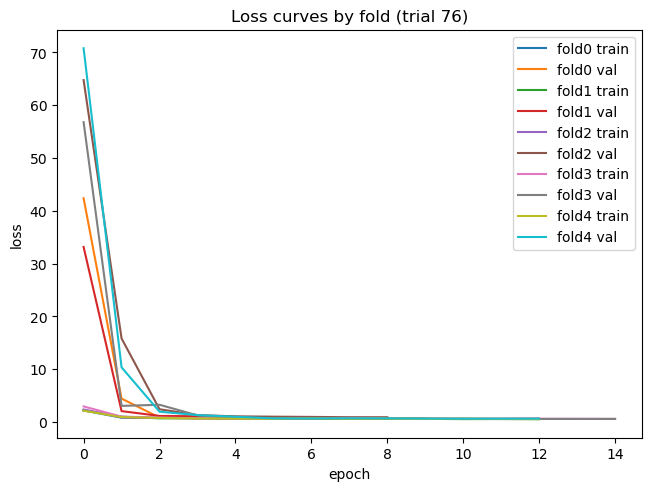

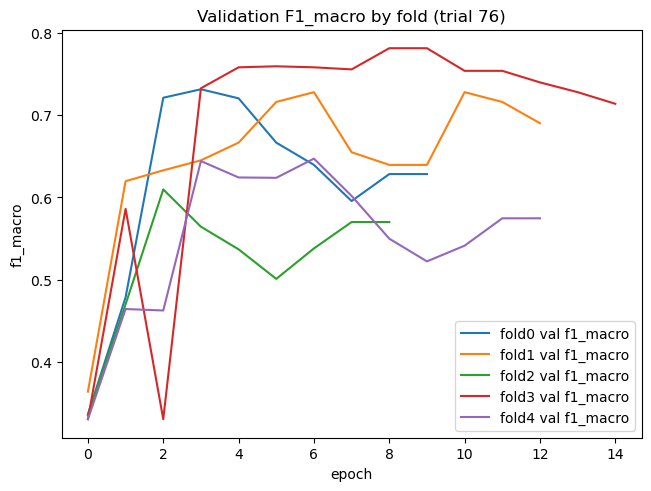

In [14]:
import matplotlib.pyplot as plt

# --- выбери trial по номеру (надёжнее, чем индекс в списке) ---
trial_number = 76
t = study.get_trials(deepcopy=False)[trial_number]  # если номера идут подряд, ок
# более надёжно, если есть пропуски:
# t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

print("Trial number:", t.number)
print("Values (f1, slope):", t.values)
print("Params:", t.params)

# --- новая номенклатура: fold_curves ---
fold_curves = t.user_attrs.get("fold_curves", None)

if fold_curves is not None and len(fold_curves) > 0:
    # 1) Loss curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        tr_losses = fc.get("train_losses", [])
        va_losses = fc.get("val_losses", [])
        if tr_losses:
            plt.plot(tr_losses, label=f"{name} train")
        if va_losses:
            plt.plot(va_losses, label=f"{name} val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves by fold (trial {t.number})")
    plt.legend()
    plt.show()

    # 2) F1 curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        va_f1s = fc.get("val_f1s", [])
        if va_f1s:
            plt.plot(va_f1s, label=f"{name} val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro by fold (trial {t.number})")
    plt.legend()
    plt.show()

else:
    # --- fallback: старая номенклатура ---
    train_losses = t.user_attrs.get("train_losses", [])
    val_losses   = t.user_attrs.get("val_losses", [])
    val_f1s      = t.user_attrs.get("val_f1s", [])

    plt.figure(constrained_layout=True)
    if train_losses:
        plt.plot(train_losses, label="train loss")
    if val_losses:
        plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves (trial {t.number})")
    plt.legend()
    plt.show()

    plt.figure(constrained_layout=True)
    if val_f1s:
        plt.plot(val_f1s, label="val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro (trial {t.number})")
    plt.legend()
    plt.show()